In [1]:
import warnings

warnings.filterwarnings("ignore")

import sys
import os


import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

import re
from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from lightgbm import LGBMRegressor
from sklearn.linear_model import (
    LassoCV,
    Lasso,
)


sys.path.append(os.path.abspath("../"))
from dmldid.simdata_genrater import generate_simdata_ro, convert_rcs

# Verification with simulation data
## simulation data
-  repeated cross-section data
- true ATT := 3
- dim(X) := 100
- N = 500

In [14]:
df_rcs =  convert_rcs(
    generate_simdata_ro(true_att=3, _n=1000, _dim=10, base_seed=1, xd_unobserved=False)
)

df_rcs.head()

,x0,x1,x2,x3,x4,x5,x6,x7,x8,x9,D,Y,T
0,1.624345,-0.611756,-0.528172,-1.072969,0.865408,-2.301539,1.744812,-0.761207,0.319039,-0.249370,1,-3.346477,0
1,1.462108,-2.060141,-0.322417,-0.384054,1.133769,-1.099891,-0.172428,-0.877858,0.042214,0.582815,0,-5.662332,1
2,-1.100619,1.144724,0.901591,0.502494,0.900856,-0.683728,-0.122890,-0.935769,-0.267888,0.530355,1,-5.225313,0
3,-0.691661,-0.396754,-0.687173,-0.845206,-0.671246,-0.012665,-1.117310,0.234416,1.659802,0.742044,0,-8.170054,0
4,-0.191836,-0.887629,-0.747158,1.692455,0.050808,-0.636996,0.190915,2.100255,0.120159,0.617203,0,-7.171957,0


In [15]:
y_col = "Y"
d_col = "D"
t_col = "T"
X_cols = [col for col in df_rcs.columns if "x" in col]

## Chang(2022)'s l2k model

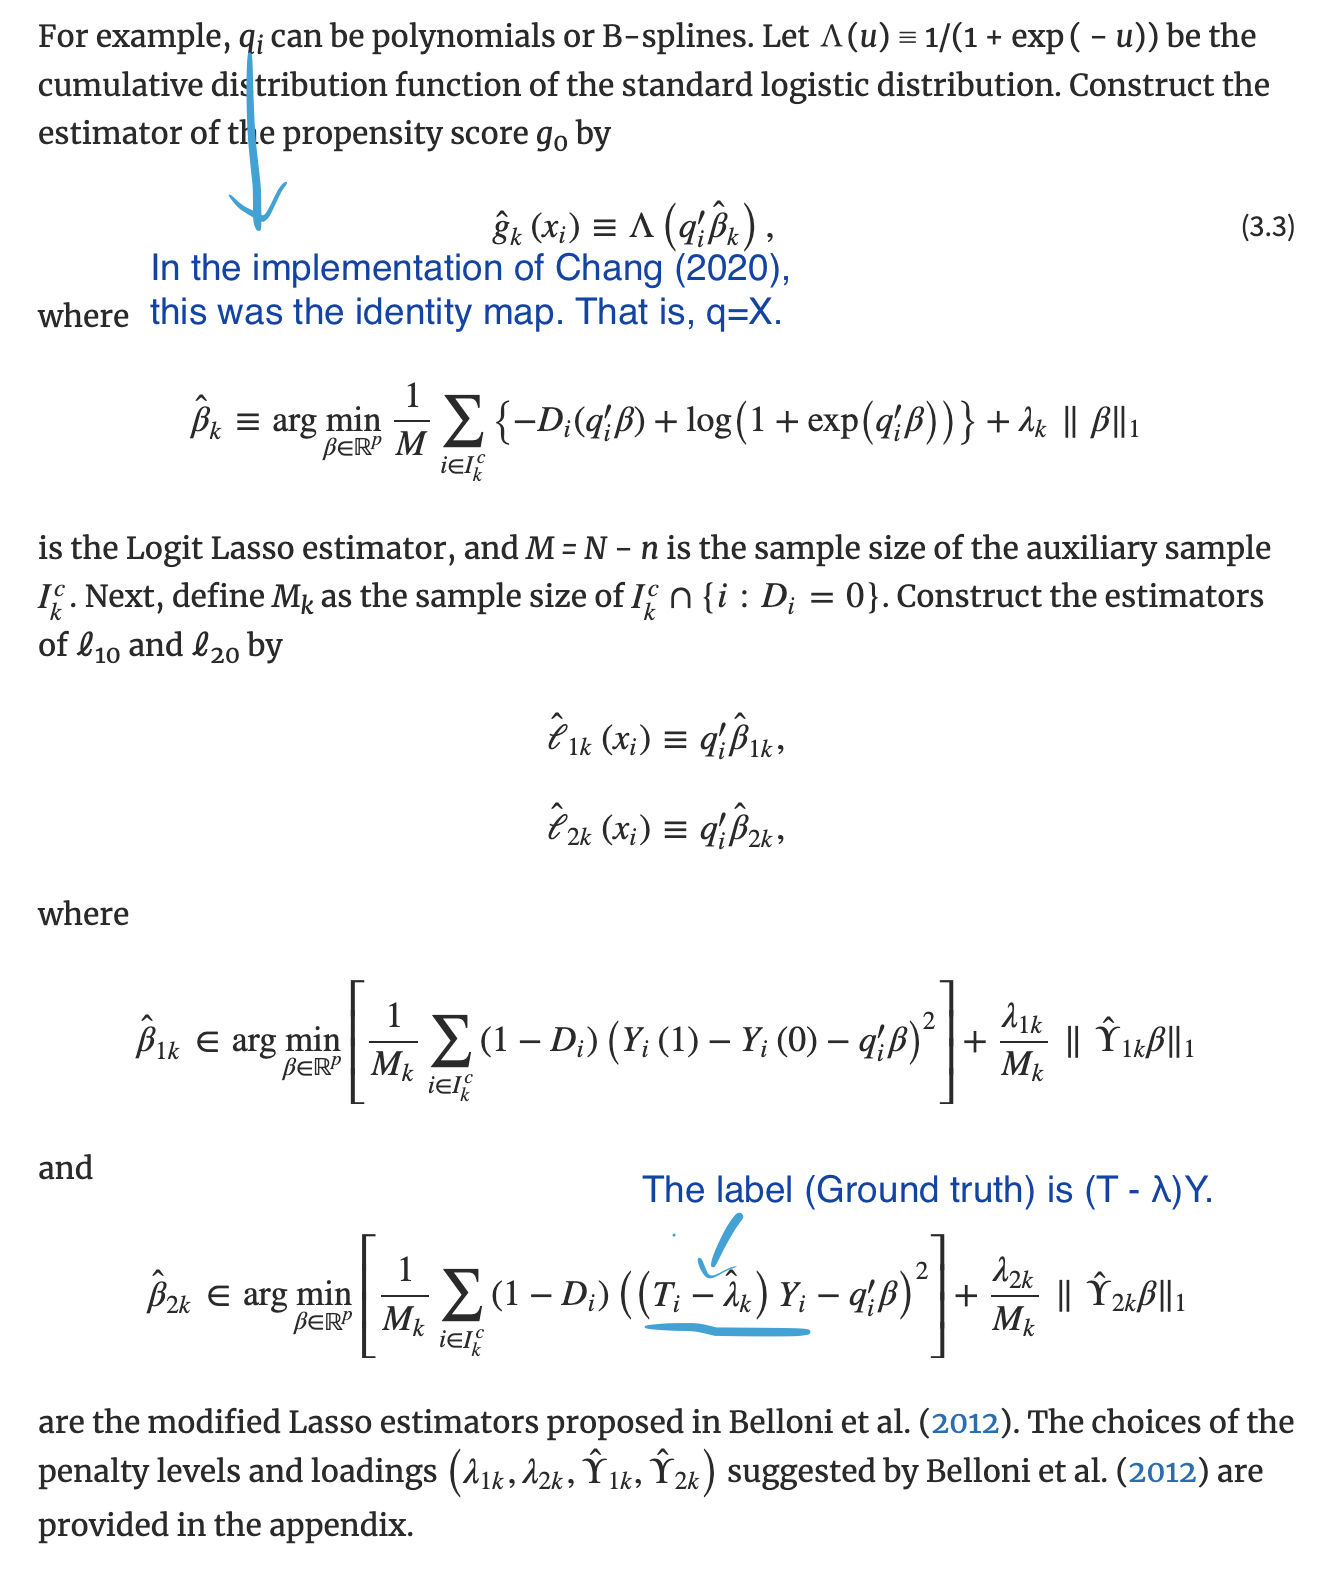

## [X -> l2k label] regression is almost nonsense
### simple example

In [16]:
hat_lambda = df_rcs["T"].mean()

control_df = df_rcs.query("D < 1")
control_df["l2k_y"] = (control_df["T"] - hat_lambda) * control_df["Y"]

In [17]:
control_df[X_cols + ["Y"]].corr()[["Y"]]

,Y
x0,0.432706
x1,0.291136
x2,0.280328
x3,0.248390
x4,0.309440
x5,0.056671
x6,-0.075762
x7,0.063368
x8,0.026195
x9,0.019046


Text(0.5, 1.0, 'the regression(X -> l2k label) dones not make sense ')

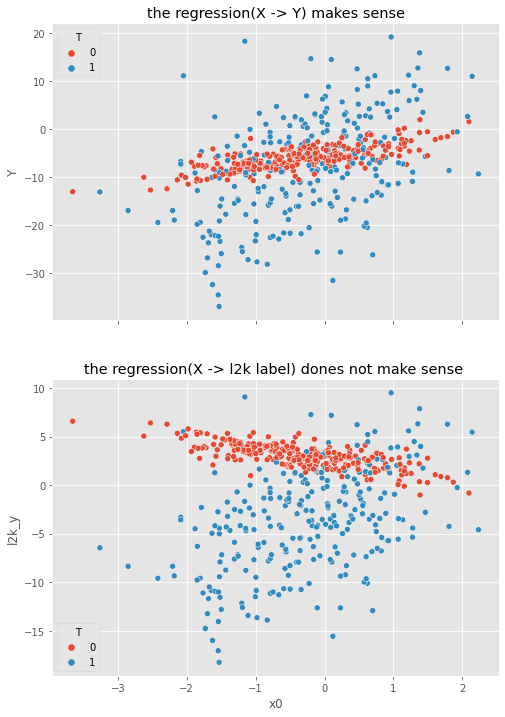

In [18]:
fig, axs = plt.subplots(2, 1, figsize=(8, 12), sharex=True)

sns.scatterplot(x="x0", y="Y", hue="T", data=control_df, ax=axs[0])
axs[0].set_title("the regression(X -> Y) makes sense")


sns.scatterplot(x="x0", y="l2k_y", hue="T", data=control_df, ax=axs[1])
axs[1].set_title("the regression(X -> l2k label) dones not make sense ")

## (1) simple regression result


In [19]:
x_train, x_test, y_train, y_test, l2k_y_train, l2k_y_test = train_test_split(
    control_df[X_cols + [t_col]],
    control_df[y_col],
    control_df["l2k_y"],
    test_size=0.3,
    random_state=0,
)


y_model = LassoCV(cv=5, random_state=0)
l2k_model = LassoCV(cv=5, random_state=0)

y_model.fit(x_train, y_train)
l2k_model.fit(x_train, l2k_y_train)

y_pred = y_model.predict(x_test)
y_mse = mean_squared_error(y_test, y_pred)

l2k_y_pred = l2k_model.predict(x_test)
l2k_mse = mean_squared_error(l2k_y_test, l2k_y_pred)

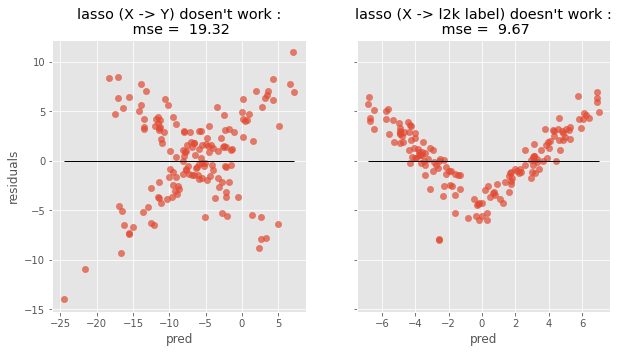

In [20]:
fig, axs = plt.subplots(1, 2, figsize=(10, 5), sharey=True)

axs[0].scatter(
    y_pred, y_pred - y_test, marker="o", s=40, alpha=0.7, label="y regression"
)
axs[0].set_xlabel("pred")
axs[0].set_ylabel("residuals")
axs[0].hlines(y=0, xmin=y_pred.min(), xmax=y_pred.max(), lw=1, color="black")
axs[0].set_title(f"lasso (X -> Y) dosen't work :\n mse = {y_mse : .2f}")

axs[1].scatter(
    l2k_y_pred,
    l2k_y_pred - l2k_y_test,
    marker="o",
    s=40,
    alpha=0.7,
    label="l2k regression",
)

axs[1].set_xlabel("pred")
axs[1].hlines(y=0, xmin=l2k_y_pred.min(), xmax=l2k_y_pred.max(), lw=1, color="black")
axs[1].set_title(f"lasso (X -> l2k label) doesn't work :\n mse = {l2k_mse : .2f}")

plt.show()

## (2) separate model on T

In [21]:
control_df_t1 = control_df.query("T>0")
control_df_t0 = control_df.query("T<1")

x_train_t1, x_test_t1, y_train_t1, y_test_t1 = train_test_split(
    control_df_t1[X_cols + [t_col]],
    control_df_t1[y_col],
    test_size=0.3,
    random_state=0,
)

x_train_t0, x_test_t0, y_train_t0, y_test_t0 = train_test_split(
    control_df_t0[X_cols + [t_col]],
    control_df_t0[y_col],
    test_size=0.3,
    random_state=0,
)


y_model_t1 = LassoCV(cv=5, random_state=0)
y_model_t0 = LassoCV(cv=5, random_state=0)

y_model_t1.fit(x_train_t1, y_train_t1)
y_model_t0.fit(x_train_t0, y_train_t0)

y_pred_t1 = y_model_t1.predict(x_test_t1)
y_mse_t1 = mean_squared_error(y_test_t1, y_pred_t1)

y_pred_t0 = y_model_t0.predict(x_test_t0)
y_mse_t0 = mean_squared_error(y_test_t0, y_pred_t0)

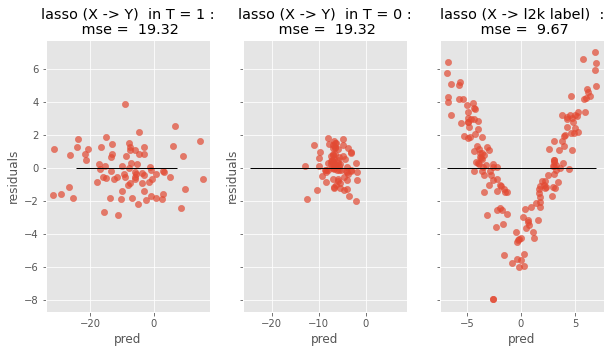

In [23]:
fig, axs = plt.subplots(1, 3, figsize=(10, 5), sharey=True)

axs[0].scatter(
   y_pred_t1, y_pred_t1 - y_test_t1, marker="o", s=40, alpha=0.7, label="y regression_t1"
)
axs[0].set_xlabel("pred")
axs[0].set_ylabel("residuals")
axs[0].hlines(y=0, xmin=y_pred.min(), xmax=y_pred.max(), lw=1, color="black")
axs[0].set_title(f"lasso (X -> Y)  in T = 1 :\n mse = {y_mse : .2f}")

axs[1].scatter(
   y_pred_t0, y_pred_t0 - y_test_t0, marker="o", s=40, alpha=0.7, label="y regression_t0"
)
axs[1].set_xlabel("pred")
axs[1].set_ylabel("residuals")
axs[1].hlines(y=0, xmin=y_pred.min(), xmax=y_pred.max(), lw=1, color="black")
axs[1].set_title(f"lasso (X -> Y)  in T = 0 :\n mse = {y_mse : .2f}")


axs[2].scatter(
    l2k_y_pred,
    l2k_y_pred - l2k_y_test,
    marker="o",
    s=40,
    alpha=0.7,
    label="l2k regression",
)

axs[2].set_xlabel("pred")
axs[2].hlines(y=0, xmin=l2k_y_pred.min(), xmax=l2k_y_pred.max(), lw=1, color="black")
axs[2].set_title(f"lasso (X -> l2k label)  :\n mse = {l2k_mse : .2f}")

plt.show()